In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler

In [71]:
df = pd.read_csv('../../data/energy.csv')
df.head()

,timestamp,load,temp
0,2012-01-01 00:00:00,2698.0,32.000000
1,2012-01-01 01:00:00,2558.0,32.666667
2,2012-01-01 02:00:00,2444.0,30.000000
3,2012-01-01 03:00:00,2402.0,31.000000
4,2012-01-01 04:00:00,2403.0,32.000000


In [72]:
print(df['timestamp'].max())
print(df['timestamp'].min())

2014-12-31 23:00:00
2012-01-01 00:00:00


In [73]:
start_train_date = '2014-11-01 00:00:00'
start_test_date = '2014-12-30 23:59:59'

scaler = MinMaxScaler()
df['temp'] = scaler.fit_transform(df[['temp']])

train_df = df[(df['timestamp'] >= start_train_date) & (df['timestamp'] < start_test_date)]
test_df = df[df['timestamp'] >= start_test_date]

print("Train data:")
print(train_df.head())

print('')
print("Test data:")
print(test_df.head())

Train data:
                 timestamp    load      temp
24840  2014-11-01 00:00:00  2514.0  0.478528
24841  2014-11-01 01:00:00  2434.0  0.469325
24842  2014-11-01 02:00:00  2390.0  0.460123
24843  2014-11-01 03:00:00  2382.0  0.460123
24844  2014-11-01 04:00:00  2419.0  0.457055

Test data:
                 timestamp    load      temp
26280  2014-12-31 00:00:00  3149.0  0.223926
26281  2014-12-31 01:00:00  3055.0  0.220859
26282  2014-12-31 02:00:00  3014.0  0.233129
26283  2014-12-31 03:00:00  3025.0  0.242331
26284  2014-12-31 04:00:00  3115.0  0.239264


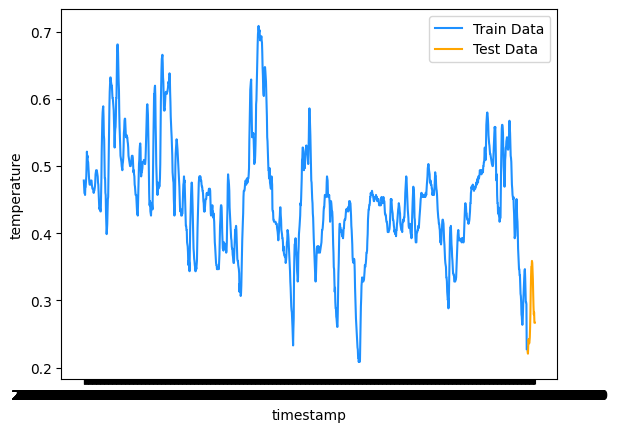

In [74]:
plt.plot(train_df['timestamp'], train_df['temp'], color='dodgerblue', label="Train Data")
plt.plot(test_df['timestamp'], test_df['temp'], color='orange', label="Test Data")

plt.xlabel("timestamp")
plt.ylabel("temperature")

plt.legend()
plt.show()

In [75]:
seq_length = 5

def create_sequence(data):
    x_train = []
    y_train = []

    for i in range(len(data) - seq_length):
        x_train.append(data.iloc[i:i+seq_length]['temp'])
        y_train.append(data.iloc[i+seq_length]['temp'])

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    return x_train, y_train

x_train, y_train = create_sequence(train_df)
x_test, y_test = create_sequence(test_df)

print("x train shape:", x_train.shape)
print("y train shape:", y_train.shape)

print("x test shape:", x_test.shape)
print("y test shape:", y_test.shape)

x train shape: (1435, 5)
y train shape: (1435,)
x test shape: (19, 5)
y test shape: (19,)


In [76]:
model = SVR()
model.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [77]:
y_pred = model.predict(x_test)

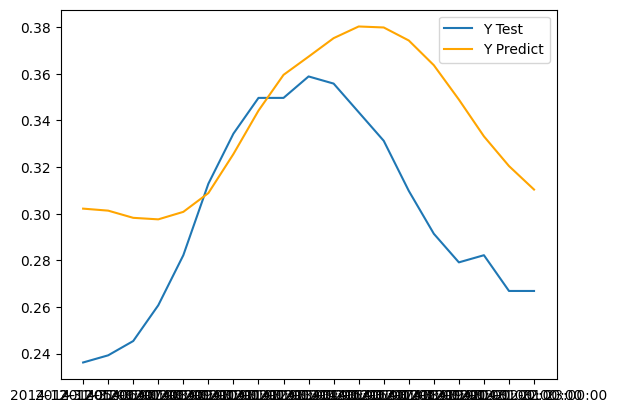

In [78]:
x = test_df['timestamp'][seq_length:]
plt.plot(x, y_test, label="Y Test")
plt.plot(x, y_pred, label="Y Predict", color='orange')

plt.legend()
plt.show()